# Condition Analysis

Structured exploration of what learned conditions do in the CoSiR combiner.

Each training sample has a small learned vector (the **condition**) in a low-dimensional space
(here 2D). The **combiner** takes a CLIP text embedding and a condition vector and produces a
new text embedding that should be closer to the paired image. This notebook asks:

- What structure exists in the condition space?
- Do conditions encode caption type (description / impression / aesthetic / caption)?
- How does moving a condition in different directions affect text–image alignment?
- Which text types benefit most from specific conditions vs any condition?

**Sections:**

1. Condition space scatter
2. Directional sweep
3. Radial sweep
4. Type-mean condition matrix
5. Per-image deep dive
6. CLIP text-image gap by caption type
7. Zero-condition ablation
8. Per-representative × per-type rank heatmap
9. Epoch evolution of type-mean trajectories
10. Condition type separability

**Data sources:**

- `<exp>/condition_viz/fixed_data.pt` — frozen CLIP embeddings + test caption types
- `<exp>/condition_viz/epoch_XXXX.pt` — training conditions + combiner weights
- `impressions_train.json` — fallback if `train_sample_types` absent from old snapshots


In [1]:
# ── CONFIG ───────────────────────────────────────────────────────────────────
EXPERIMENT_DIR = (
    "/project/CoSiR/res/CoSiR_Experiment/impressions/20260423_215420_CoSiR_Experiment"
)
TRAIN_JSON_PATH = "/project/Impressions/metadata/impressions_train.json"
EPOCH = None  # None → latest
DEVICE = "cuda"
N_SWEEP = 21
N_QUERIES = 30
N_RETRIEVE = 5
N_MAT = 100  # texts per type for matrix/ablation cells
# ─────────────────────────────────────────────────────────────────────────────

TYPE_NAMES = ["caption", "description", "impression", "aesthetic"]
TYPE_COLORS = ["#888888", "#2196F3", "#FF9800", "#4CAF50"]

In [2]:
import os, sys, glob, json, textwrap
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from PIL import Image

sys.path.insert(
    0, os.path.join(os.path.dirname(os.path.abspath("__file__")), "../../..")
)
from src.model.combiner import Combiner_new

cond_dir = os.path.join(EXPERIMENT_DIR, "condition_viz")

fixed = torch.load(os.path.join(cond_dir, "fixed_data.pt"), map_location="cpu")
all_img_emb = fixed["all_img_emb"]
all_txt_emb = fixed["all_txt_emb"]
all_raw_text = fixed["all_raw_text"]
image_paths = fixed["image_paths"]
img2txt = fixed["image_to_text_map"]
txt2img = fixed["text_to_image_map"]
cpi = fixed["captions_per_image"]
test_cap_types = fixed.get("test_caption_types")
n_img, n_txt = all_img_emb.shape[0], all_txt_emb.shape[0]
print(f"Test set: {n_img} images × {cpi} caps = {n_txt} texts")

if test_cap_types is None:
    _test_json = os.path.join(os.path.dirname(TRAIN_JSON_PATH), "impressions_test.json")
    _test_anns = json.load(open(_test_json))
    _tm = {"caption": 0, "description": 1, "impression": 2, "aesthetic": 3}
    test_cap_types = torch.tensor(
        [_tm[t] for ann in _test_anns for t in ann["caption_type"]], dtype=torch.long
    )
    print(f"  Reconstructed test_caption_types: {test_cap_types.shape}")

epoch_files = sorted(glob.glob(os.path.join(cond_dir, "epoch_*.pt")))
snap_path = (
    epoch_files[-1]
    if EPOCH is None
    else os.path.join(cond_dir, f"epoch_{EPOCH:04d}.pt")
)
snap = torch.load(snap_path, map_location="cpu", weights_only=False)
epoch = snap["epoch"]
label_emb_all = snap["label_embeddings_all"]
representatives = snap["representatives"]
combiner_cfg = snap["combiner_config"]
train_types = snap.get("train_sample_types")
K = representatives.shape[0]
label_dim = label_emb_all.shape[1]
print(
    f"Epoch {epoch} | {label_emb_all.shape[0]} train conditions | dim={label_dim} | {K} reps"
)

if train_types is None:
    _train_anns = json.load(open(TRAIN_JSON_PATH))
    _tm = {"caption": 0, "description": 1, "impression": 2, "aesthetic": 3}
    train_types = torch.tensor(
        [_tm[a["caption_type"]] for a in _train_anns], dtype=torch.long
    )
    print(f"  Reconstructed train_types: {train_types.shape}")

combiner = Combiner_new(**combiner_cfg).to(DEVICE)
combiner.load_state_dict(snap["combiner_state_dict"])
combiner.eval()
print("Combiner loaded.")

Test set: 706 images × 4 caps = 2824 texts
Epoch 999 | 12123 train conditions | dim=16 | 30 reps
Combiner loaded.


In [3]:
@torch.no_grad()
def apply_condition(txt_emb: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
    if cond.dim() == 1:
        cond = cond.unsqueeze(0).expand(txt_emb.shape[0], -1)
    return combiner(txt_emb.to(DEVICE), None, cond.to(DEVICE)).cpu()


def cos_sim(a, b):
    return F.cosine_similarity(F.normalize(a, dim=-1), F.normalize(b, dim=-1), dim=-1)


def get_query_indices(cap_type: int, n: int):
    return (test_cap_types == cap_type).nonzero(as_tuple=True)[0][:n]


@torch.no_grad()
def mean_gt_rank(txt_emb, q_idx):
    scores = F.normalize(txt_emb, dim=-1) @ img_n.T
    return float(
        np.mean(
            [
                (scores[b] > scores[b, txt2img[tidx].item()]).sum().item() + 1
                for b, tidx in enumerate(q_idx.tolist())
            ]
        )
    )


def _img(idx):
    try:
        return Image.open(image_paths[idx]).convert("RGB")
    except:
        return None


img_n = F.normalize(all_img_emb, dim=-1)
txt_n = F.normalize(all_txt_emb, dim=-1)

type_means = {t: label_emb_all[train_types == t].mean(0) for t in range(4)}

print(f"{'Type':12s}  {'N':>6}  {'‖μ‖':>8}  {'σ_avg':>8}")
for t in range(4):
    pts = label_emb_all[train_types == t]
    print(
        f"{TYPE_NAMES[t]:12s}  {pts.shape[0]:>6}  {type_means[t].norm().item():8.4f}  {pts.std(0).mean().item():8.4f}"
    )

# ── 2D projection for visualization (adapts to embedding_dim > 2) ──────────
if label_dim == 2:
    label_emb_2d = label_emb_all.numpy()
    type_means_2d = {t: type_means[t].numpy() for t in range(4)}
    _proj_for_means = None
    dim_label = "dim"
else:
    from src.model.clustering import UMAP_vis

    _umap_vis = UMAP_vis(device=DEVICE)
    label_emb_2d = _umap_vis.learn_umap(label_emb_all, close_cluster=True)
    # Type means: nearest-neighbor lookup so they land in the UMAP space
    type_means_2d = {}
    for _t in range(4):
        _tm_idx = (
            torch.cdist(type_means[_t].unsqueeze(0).float(), label_emb_all.float())
            .argmin(dim=1)
            .item()
        )
        type_means_2d[_t] = label_emb_2d[_tm_idx]
    # PCA fitted on current epoch — used for consistent projection of per-epoch means
    from sklearn.decomposition import PCA as _PCA

    _proj_for_means = _PCA(n_components=2).fit(label_emb_all.numpy())
    dim_label = "UMAP dim"

# Representatives: index lookup into label_emb_all → UMAP-projected coords
rep_indices = (
    torch.cdist(representatives.float(), label_emb_all.float()).argmin(dim=1).numpy()
)
reps_2d = label_emb_2d[rep_indices]

print(
    f"2D projection ready ({'UMAP' if label_dim > 2 else 'raw'}, shape={label_emb_2d.shape})"
)

Type               N       ‖μ‖     σ_avg
caption         1423    3.2215    2.7702
description     3565    3.7156    2.6055
impression      3566    3.3256    2.7882
aesthetic       3569    2.2115    2.8043
[2026-04-24 00:43:26.822] [CUML] [info] build_algo set to brute_force_knn because random_state is given
2D projection ready (UMAP, shape=(12123, 2))


---

## 1 — Condition Space: Training Conditions Colored by Caption Type

**What this shows.**
Each of the 12 K training samples has a learned 2D condition vector. The left scatter plot shows
all of them at once, colored by the caption type (`caption` / `description` / `impression` /
`aesthetic`). Stars mark the per-type mean. The right panel shows box plots of each dimension's
distribution separated by type.

**How to read it.**

- **Tight, separated color clusters → conditions strongly encode caption type.**
  If the four clouds overlap heavily, caption type is a weak signal in condition space.
- **Star positions (type means):** even if clouds overlap, the means can still be systematically
  offset — look at whether `description` and `impression` means point in clearly different directions.
- **Box plot medians:** a consistent shift in the median across types (even small) is a real,
  learned bias. The spread (box height) quantifies how much per-sample variation lies on top of
  the type-level signal.
- **`‖μ‖` in the printout:** larger norm → the average condition for that type points further from
  the origin, meaning the combiner receives a stronger systematic push for that type.


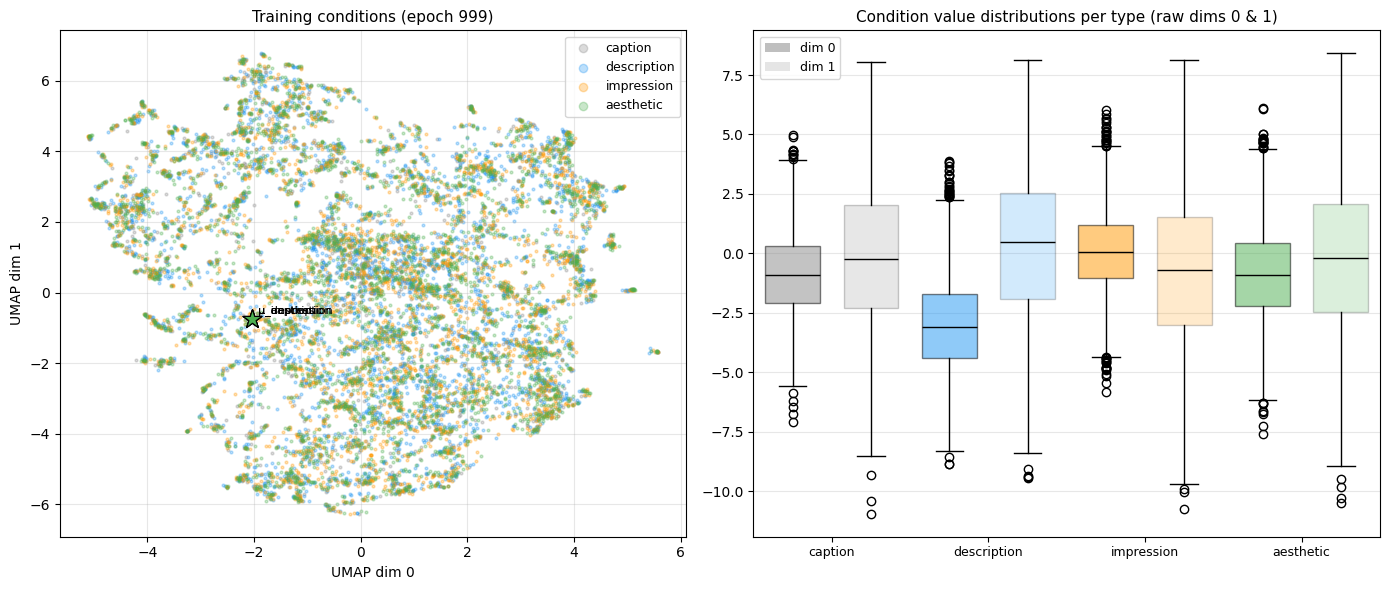

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
_train_types_np = train_types.numpy()
for t in range(4):
    pts = label_emb_2d[_train_types_np == t]
    ax.scatter(
        pts[:, 0],
        pts[:, 1],
        s=4,
        alpha=0.3,
        color=TYPE_COLORS[t],
        label=TYPE_NAMES[t],
        rasterized=True,
    )
for t in range(4):
    m = type_means_2d[t]
    ax.scatter(
        m[0],
        m[1],
        s=200,
        color=TYPE_COLORS[t],
        marker="*",
        edgecolors="black",
        linewidths=0.8,
        zorder=5,
    )
    ax.annotate(
        f"μ_{TYPE_NAMES[t]}", m, fontsize=8, xytext=(4, 4), textcoords="offset points"
    )
ax.set_title(f"Training conditions (epoch {epoch})", fontsize=11)
ax.set_xlabel(f"{dim_label} 0")
ax.set_ylabel(f"{dim_label} 1")
ax.legend(markerscale=3, fontsize=9)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
pos0, pos1 = [1, 3, 5, 7], [2, 4, 6, 8]
bp0 = ax2.boxplot(
    [label_emb_all[train_types == t, 0].numpy() for t in range(4)],
    positions=pos0,
    widths=0.7,
    patch_artist=True,
    medianprops=dict(color="black"),
    boxprops=dict(facecolor="none"),
)
bp1 = ax2.boxplot(
    [label_emb_all[train_types == t, 1].numpy() for t in range(4)],
    positions=pos1,
    widths=0.7,
    patch_artist=True,
    medianprops=dict(color="black"),
    boxprops=dict(facecolor="none", linestyle="--"),
)
for patch, c in zip(bp0["boxes"], TYPE_COLORS):
    patch.set_facecolor(c)
    patch.set_alpha(0.5)
for patch, c in zip(bp1["boxes"], TYPE_COLORS):
    patch.set_facecolor(c)
    patch.set_alpha(0.2)
ax2.set_xticks([(a + b) / 2 for a, b in zip(pos0, pos1)])
ax2.set_xticklabels(TYPE_NAMES, fontsize=9)
ax2.set_title("Condition value distributions per type (raw dims 0 & 1)", fontsize=11)
ax2.legend(
    [
        mpatches.Patch(facecolor="grey", alpha=0.5),
        mpatches.Patch(facecolor="grey", alpha=0.2),
    ],
    ["dim 0", "dim 1"],
    fontsize=9,
)
ax2.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

---

## 2 — Directional Sweep

**What this shows.**
A condition is slid along a chosen direction (one row per direction) and applied to test texts.
Two directions are tested: the vector from `description` mean to `impression` mean, and the first
principal component of all training conditions.

**How to read it.**

- **Left column — `cos_sim(conditioned_txt, original_txt)`:**
  Measures how far the conditioned text has moved from the original text embedding.
  - **Value closer to 1.0 = text barely moved.** At `t = 0` (origin of the sweep) this should
    be near 1.
  - **Value further from 1.0 = text was displaced more** by the condition. A large drop means
    the combiner is applying a strong transformation.
  - Observe whether different text types (colors) are displaced by the same amount — if one
    type's curve drops faster, the combiner is more sensitive to conditions for that type.

- **Right column — `cos_sim(conditioned_txt, matching_image)`:**
  Measures alignment between the conditioned text and its GT image.
  - **Higher = better.** A peak in this curve indicates the optimal condition position for
    that text type along this direction.
  - If the peak for `description` texts is at a different `t` than for `impression` texts,
    the two types need different conditions on this axis — direct evidence of type-specificity.

- **Dotted vertical lines:** project each type's mean condition onto this direction. If the
  image-similarity peak for a text type aligns with its own type-mean dotted line, the model
  has learned to push that type toward its optimal direction.

- **Curves for all four text types** are shown on the same axes. Flat curves (no peak) mean
  the direction is irrelevant for that type. Peaked curves indicate the direction is meaningful.


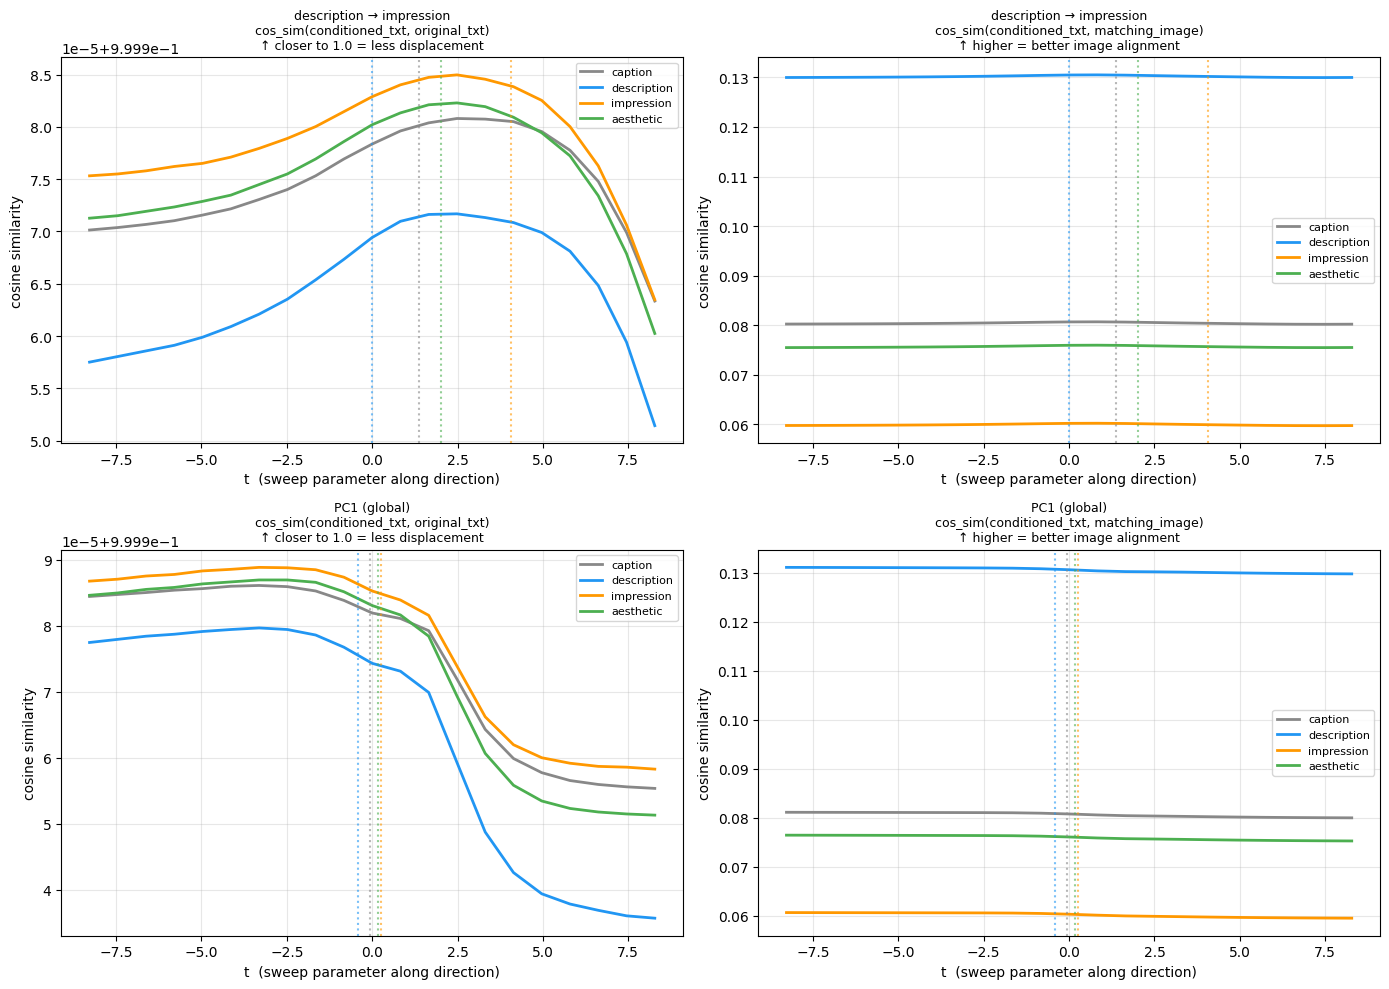

In [5]:
_d2i = type_means[2] - type_means[1]
dir_desc2imp = _d2i / (_d2i.norm() + 1e-8)
_cov = torch.cov(label_emb_all.T)
dir_pc1 = torch.linalg.eigh(_cov)[1][:, -1]

directions = {
    "description → impression": (dir_desc2imp, type_means[1]),
    "PC1 (global)": (dir_pc1, label_emb_all.mean(0)),
}
_span = (label_emb_all @ dir_desc2imp.unsqueeze(1)).squeeze().std().item() * 3
t_vals = torch.linspace(-_span, _span, N_SWEEP)

fig, axes = plt.subplots(len(directions), 2, figsize=(14, 5 * len(directions)))
if len(directions) == 1:
    axes = axes[np.newaxis]

for row, (dir_name, (direction, origin)) in enumerate(directions.items()):
    results = {t: {"orig": [], "img": []} for t in range(4)}
    for t in range(4):
        q_idx = get_query_indices(t, N_QUERIES)
        txt_q, img_q = all_txt_emb[q_idx], img_n[txt2img[q_idx]]
        orig_n = F.normalize(txt_q, dim=-1)
        for tv in t_vals:
            ct = apply_condition(txt_q, origin + direction * tv)
            results[t]["orig"].append(cos_sim(ct, orig_n).mean().item())
            results[t]["img"].append(cos_sim(ct, img_q).mean().item())

    tv_np = t_vals.numpy()
    for col, key in enumerate(["orig", "img"]):
        ax = axes[row, col]
        for t in range(4):
            ax.plot(
                tv_np, results[t][key], color=TYPE_COLORS[t], label=TYPE_NAMES[t], lw=2
            )
        for t in range(4):
            p = float((type_means[t] - origin) @ direction)
            ax.axvline(p, color=TYPE_COLORS[t], linestyle=":", alpha=0.6)
        if key == "orig":
            ax.set_title(
                f"{dir_name}\ncos_sim(conditioned_txt, original_txt)\n↑ closer to 1.0 = less displacement",
                fontsize=9,
            )
        else:
            ax.set_title(
                f"{dir_name}\ncos_sim(conditioned_txt, matching_image)\n↑ higher = better image alignment",
                fontsize=9,
            )
        ax.set_xlabel("t  (sweep parameter along direction)")
        ax.set_ylabel("cosine similarity")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 3 — Radial Sweep

**What this shows.**
Instead of a direction, here we vary the **magnitude** and **angle** of the condition independently.
Queries used: `description` text type (representative of well-formed captions).

**How to read — 3a (vary radius, fixed direction):**

- X-axis = condition norm (distance from origin in condition space).
- One curve per type-mean direction (the combiner is probed in the direction of each type's average).
- **Left plot, `cos_sim` to original text:** as radius grows, the text is displaced further from
  its original embedding. A faster-falling curve = that direction is more disruptive.
- **Right plot, `cos_sim` to matching image:** look for a **peak** — the radius at which text-image
  alignment is maximised. If alignment keeps rising with radius, bigger conditions are always
  better. If it peaks and then falls, there is an optimal condition magnitude beyond which the
  combiner overshoots.
- The **dashed vertical line** marks the median training condition norm — the typical magnitude
  the model actually uses.

**How to read — 3b (vary angle, fixed radii):**

- X-axis = angle θ of the condition vector (0°–360°).
- Three curves per plot: same angle swept at 0.5×, 1.0×, 1.5× the median training norm.
- **Right plot peaks → best direction for image alignment.** A sharp peak means alignment is
  highly direction-sensitive at this radius. A flat curve means direction barely matters.
- **Dotted lines** mark the angle of each type's mean condition. If alignment peaks near one
  type's dotted line for that type's texts, the type mean is a good proxy for the optimal condition.


Median condition norm: 11.3908  |  95th pct: 13.4981


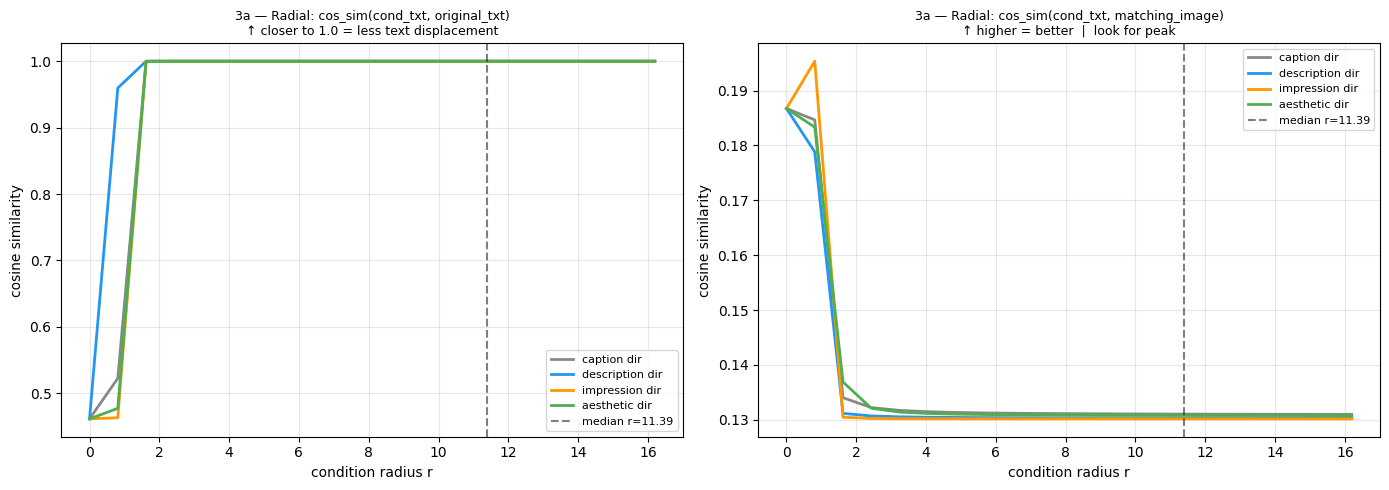

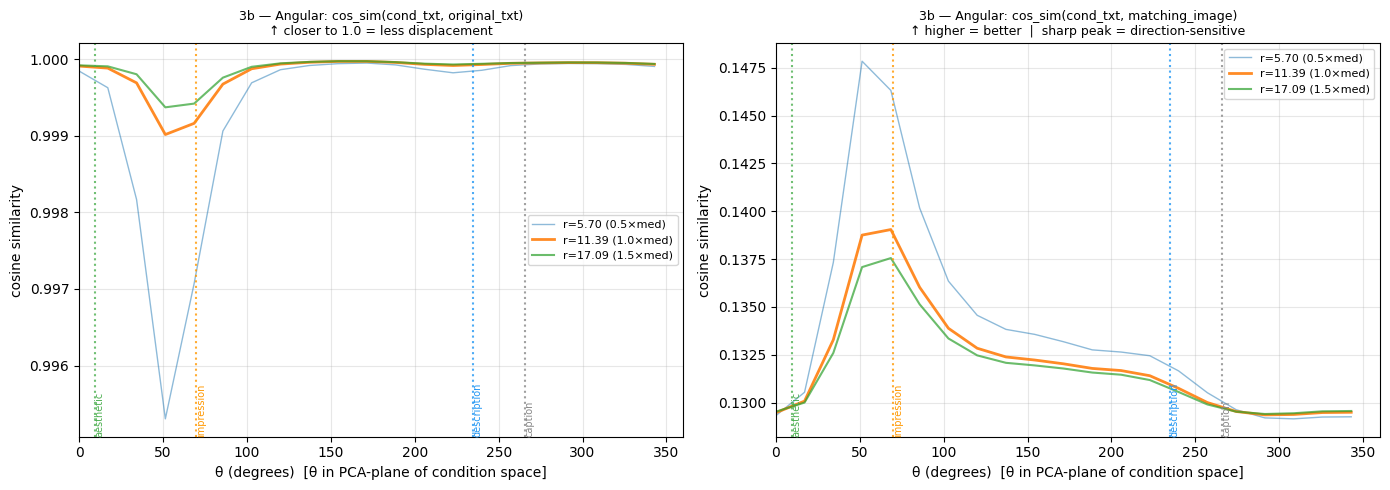

In [6]:
median_r = label_emb_all.norm(dim=-1).median().item()
max_r = label_emb_all.norm(dim=-1).quantile(0.95).item()
print(f"Median condition norm: {median_r:.4f}  |  95th pct: {max_r:.4f}")

_q_idx = get_query_indices(1, N_QUERIES)
_txt_q, _img_q = all_txt_emb[_q_idx], img_n[txt2img[_q_idx]]
_orig_n = F.normalize(_txt_q, dim=-1)

r_vals = torch.linspace(0, max_r * 1.2, N_SWEEP)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for t in range(4):
    d = type_means[t] / (type_means[t].norm() + 1e-8)
    s_orig = [
        cos_sim(apply_condition(_txt_q, d * r), _orig_n).mean().item() for r in r_vals
    ]
    s_img = [
        cos_sim(apply_condition(_txt_q, d * r), _img_q).mean().item() for r in r_vals
    ]
    axes[0].plot(
        r_vals.numpy(), s_orig, color=TYPE_COLORS[t], label=f"{TYPE_NAMES[t]} dir", lw=2
    )
    axes[1].plot(
        r_vals.numpy(), s_img, color=TYPE_COLORS[t], label=f"{TYPE_NAMES[t]} dir", lw=2
    )
for ax in axes:
    ax.axvline(
        median_r,
        color="black",
        linestyle="--",
        alpha=0.5,
        label=f"median r={median_r:.2f}",
    )
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("condition radius r")
    ax.set_ylabel("cosine similarity")
axes[0].set_title(
    "3a — Radial: cos_sim(cond_txt, original_txt)\n↑ closer to 1.0 = less text displacement",
    fontsize=9,
)
axes[1].set_title(
    "3a — Radial: cos_sim(cond_txt, matching_image)\n↑ higher = better  |  look for peak",
    fontsize=9,
)
plt.tight_layout()
plt.show()

# ── 3b: angular sweep ────────────────────────────────────────────────────────
# For label_dim==2: sweep directly in 2D polar coords.
# For label_dim>2:  sweep in the plane of the first two PCA components so that
#                   the condition vector is always label_dim-dimensional.
theta_vals = torch.linspace(0, 2 * np.pi, N_SWEEP + 1)[:-1]

if label_dim == 2:
    _basis1 = torch.tensor([1.0, 0.0])
    _basis2 = torch.tensor([0.0, 1.0])
    # Angle of each type mean in raw 2D space
    _type_angles = [
        float(np.degrees(np.arctan2(*type_means[t].numpy()[::-1]))) % 360
        for t in range(4)
    ]
    sweep_label = "θ in raw 2D condition space"
else:
    # PCA basis vectors (shape: [label_dim])
    _basis1 = torch.tensor(_proj_for_means.components_[0], dtype=torch.float32)
    _basis2 = torch.tensor(_proj_for_means.components_[1], dtype=torch.float32)
    # Angle of each type mean projected into PCA plane
    _type_angles = [
        float(
            np.degrees(
                np.arctan2(
                    float(type_means[t].float() @ _basis2),
                    float(type_means[t].float() @ _basis1),
                )
            )
        )
        % 360
        for t in range(4)
    ]
    sweep_label = "θ in PCA-plane of condition space"


def _make_cond(r, theta_rad):
    return _basis1 * (r * float(theta_rad.cos())) + _basis2 * (
        r * float(theta_rad.sin())
    )


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for r_mult, lw, alpha in [(0.5, 1, 0.5), (1.0, 2, 0.9), (1.5, 1.5, 0.7)]:
    r = median_r * r_mult
    s_o = [
        cos_sim(apply_condition(_txt_q, _make_cond(r, th)), _orig_n).mean().item()
        for th in theta_vals
    ]
    s_i = [
        cos_sim(apply_condition(_txt_q, _make_cond(r, th)), _img_q).mean().item()
        for th in theta_vals
    ]
    td = theta_vals.numpy() * 180 / np.pi
    axes[0].plot(td, s_o, lw=lw, alpha=alpha, label=f"r={r:.2f} ({r_mult}×med)")
    axes[1].plot(td, s_i, lw=lw, alpha=alpha, label=f"r={r:.2f} ({r_mult}×med)")
for t in range(4):
    for ax in axes:
        ax.axvline(
            _type_angles[t], color=TYPE_COLORS[t], linestyle=":", alpha=0.8, lw=1.5
        )
        ax.text(
            _type_angles[t],
            ax.get_ylim()[0] if ax.get_ylim()[0] != 0 else 0,
            TYPE_NAMES[t],
            fontsize=7,
            rotation=90,
            va="bottom",
            color=TYPE_COLORS[t],
        )
for ax in axes:
    ax.set_xlabel(f"θ (degrees)  [{sweep_label}]")
    ax.set_ylabel("cosine similarity")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 360)
axes[0].set_title(
    "3b — Angular: cos_sim(cond_txt, original_txt)\n↑ closer to 1.0 = less displacement",
    fontsize=9,
)
axes[1].set_title(
    "3b — Angular: cos_sim(cond_txt, matching_image)\n↑ higher = better  |  sharp peak = direction-sensitive",
    fontsize=9,
)
plt.tight_layout()
plt.show()

---

## 4 — Type-Mean Condition Matrix

**What this shows.**
A 4×4 grid: rows are the caption type of the test text being queried, columns are the type whose
mean condition is applied. This measures whether conditions trained on one type transfer usefully
to texts of a different type.

**How to read it.**

- **Left — `cos_sim(cond_txt, original_txt)` (green = high = close to 1.0):**
  How much the condition displaces the text embedding from its original position.
  - **Closer to 1.0 = small displacement** (the condition barely changed the text).
  - **Further from 1.0 = large displacement** (the condition strongly transformed the text).
  - A uniform row means all conditions displace texts of that type equally. Variation within a
    row means some conditions are more disruptive than others for this text type.

- **Middle — Mean GT rank (green = low number = better):**
  The average position of the GT image in the ranked retrieval list after conditioning.
  - **Rank 1 = GT image is the top result.** Lower is always better.
  - Compare to the CLIP baseline rank printed below the plot.

- **Right — Δ rank vs CLIP baseline (green = negative = better):**
  How much rank improved (negative) or worsened (positive) relative to no conditioning.
  - **Negative = condition helped.**
  - **Positive = condition hurt** (made retrieval worse than raw CLIP).
  - Look for: (a) is the diagonal (text type = condition type) the best row? If so, conditions
    generalise best when applied to their own type. (b) Are some text types uniformly improved
    by all conditions, or do they need the right condition?


CLIP baseline mean GT rank per text type (no conditioning):
  caption     : 35.8
  description : 1.6
  impression  : 29.1
  aesthetic   : 19.6


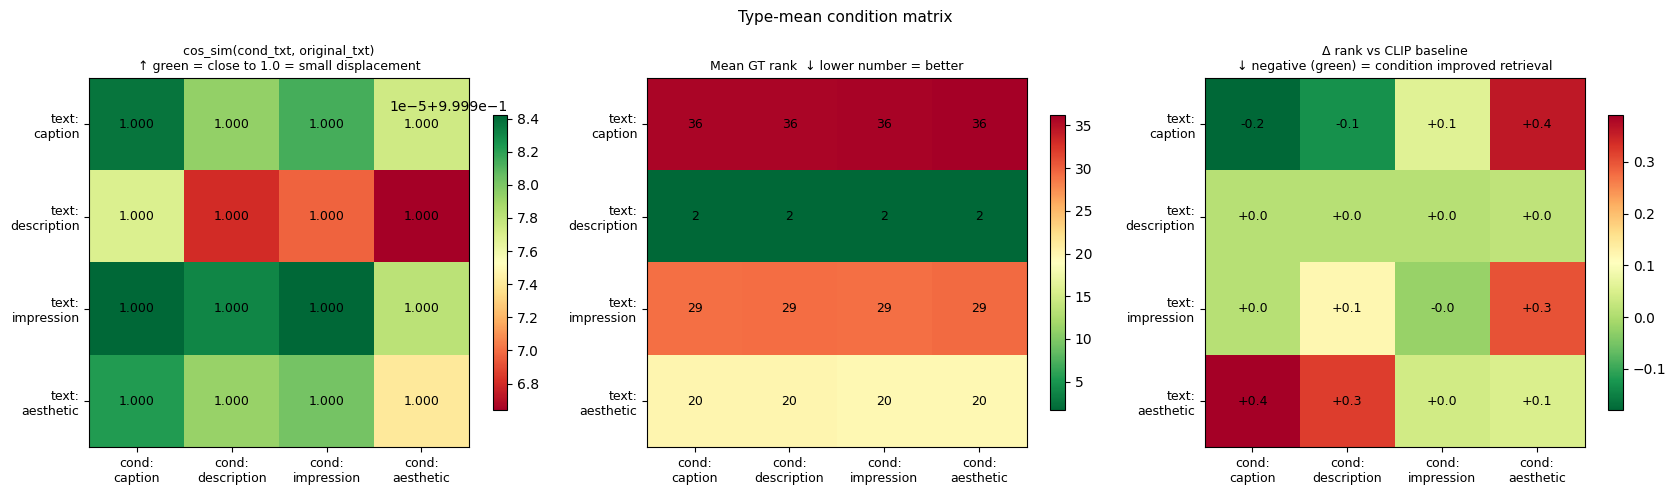

In [7]:
mat_cos = np.zeros((4, 4))
mat_rank = np.zeros((4, 4))
clip_ranks = np.zeros(4)

for r_t in range(4):
    q = get_query_indices(r_t, N_MAT)
    clip_ranks[r_t] = mean_gt_rank(all_txt_emb[q], q)
    orig_n = F.normalize(all_txt_emb[q], dim=-1)
    for c_t in range(4):
        ct = apply_condition(all_txt_emb[q], type_means[c_t])
        mat_cos[r_t, c_t] = cos_sim(ct, orig_n).mean().item()
        mat_rank[r_t, c_t] = mean_gt_rank(ct, q)

mat_delta = mat_rank - clip_ranks[:, np.newaxis]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, mat, title, cmap, fmt in [
    (
        axes[0],
        mat_cos,
        "cos_sim(cond_txt, original_txt)\n↑ green = close to 1.0 = small displacement",
        "RdYlGn",
        ".3f",
    ),
    (axes[1], mat_rank, "Mean GT rank  ↓ lower number = better", "RdYlGn_r", ".0f"),
    (
        axes[2],
        mat_delta,
        "Δ rank vs CLIP baseline\n↓ negative (green) = condition improved retrieval",
        "RdYlGn_r",
        "+.1f",
    ),
]:
    im = ax.imshow(mat, cmap=cmap, aspect="auto")
    ax.set_xticks(range(4))
    ax.set_xticklabels([f"cond:\n{n}" for n in TYPE_NAMES], fontsize=9)
    ax.set_yticks(range(4))
    ax.set_yticklabels([f"text:\n{n}" for n in TYPE_NAMES], fontsize=9)
    ax.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{mat[i,j]:{fmt}}", ha="center", va="center", fontsize=9)

print("CLIP baseline mean GT rank per text type (no conditioning):")
for t in range(4):
    print(f"  {TYPE_NAMES[t]:12s}: {clip_ranks[t]:.1f}")
fig.suptitle("Type-mean condition matrix", fontsize=11)
plt.tight_layout()
plt.show()

---

## 5 — Per-Image Deep Dive

**What this shows.**
A single test image is chosen. Its four captions (one per type, sorted by type) form the rows.
The columns show the top-5 retrieved images under: CLIP baseline (no condition) and then each
of the four type-mean conditions.

**How to read it.**

- **Green border = ground-truth image (the correct answer).**
  A green border in rank 1 means perfect retrieval.
- **Reading a row:** how does applying different condition types shift which images are retrieved
  for this specific caption?
- **Reading a column:** does this condition type consistently bring the GT image higher in rank,
  across all four caption types?
- **Interesting patterns to look for:**
  - Does the `description` condition help `description` captions more than other conditions?
    (Type-specific benefit → evidence that conditions encode type.)
  - Does any condition hurt retrieval (GT disappears from top-5 compared to CLIP)?
  - Are the retrieved non-GT images thematically similar to the query image? This tells you
    whether the condition is changing the semantic direction of the text.

Change `QUERY_IMAGE_IDX` to explore different images.


In [ ]:
QUERY_IMAGE_IDX = 0

sorted_pairs = sorted(
    zip(
        [test_cap_types[i].item() for i in img2txt[QUERY_IMAGE_IDX].tolist()],
        img2txt[QUERY_IMAGE_IDX].tolist(),
    ),
    key=lambda x: x[0],
)
row_types = [p[0] for p in sorted_pairs]
row_tidxs = [p[1] for p in sorted_pairs]


@torch.no_grad()
def topk_images(emb, k=N_RETRIEVE):
    return torch.topk(
        (F.normalize(emb.unsqueeze(0).to(DEVICE), dim=-1) @ img_n.to(DEVICE).T)
        .squeeze(0)
        .cpu(),
        k,
    ).indices.tolist()


col_labels = ["CLIP\nbaseline"] + [f"cond:\n{TYPE_NAMES[t]}" for t in range(4)]
fig, axes = plt.subplots(
    len(row_tidxs) * N_RETRIEVE,
    5,
    figsize=(8, 1.4 * len(row_tidxs) * N_RETRIEVE + 0.8),
    squeeze=False,
)

for r, (rt, tidx) in enumerate(zip(row_types, row_tidxs)):
    txt_emb = all_txt_emb[tidx]
    cols = [topk_images(txt_emb)] + [
        topk_images(apply_condition(txt_emb.unsqueeze(0), type_means[c]).squeeze(0))
        for c in range(4)
    ]
    gt = txt2img[tidx].item()
    for col, top_k in enumerate(cols):
        for rank, iidx in enumerate(top_k):
            ax = axes[r * N_RETRIEVE + rank, col]
            img = _img(iidx)
            if img:
                ax.imshow(img)
            else:
                ax.text(
                    0.5,
                    0.5,
                    f"img{iidx}",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=6,
                )
            if iidx == gt:
                for sp in ax.spines.values():
                    sp.set_edgecolor("limegreen")
                    sp.set_linewidth(3)
            ax.set_xticks([])
            ax.set_yticks([])
            if rank == 0:
                ax.set_title(col_labels[col], fontsize=7, pad=2)
            if col == 0 and rank == 0:
                ax.set_ylabel(
                    f"{TYPE_NAMES[rt]}\n(t{tidx})",
                    fontsize=7,
                    rotation=0,
                    ha="right",
                    va="center",
                    labelpad=55,
                )

fig.suptitle(
    f"Image {QUERY_IMAGE_IDX}  [epoch {epoch}]  —  green border = GT image",
    fontsize=9,
    y=1.002,
)
plt.tight_layout()
plt.show()

### 5b — PCA of Text Embeddings in CLIP Space

**What this shows.**
All four original text embeddings for this image, plus their four conditioned versions (one per
type-mean condition), projected into 2D PCA. The GT image embedding is also shown.

**How to read it.**

- **Circles (○) = original text embeddings** in CLIP space, colored by caption type.
- **Triangles (▲) = conditioned text embeddings**, with arrows showing the direction and
  magnitude of movement caused by the condition.
- **Square (■) = GT image embedding.**
- **A good condition moves the text closer to the square** (shorter vector between conditioned
  triangle and black square).
- **All triangles from the same original should cluster** toward the image if any condition works.
  If triangles scatter in different directions, different conditions are pulling the text
  toward different semantics.
- **PCA variance explained** (axis labels) indicates how much structure is captured. If PC1
  explains most variance, the dominant movement direction is a single axis.


In [ ]:
from sklearn.decomposition import PCA

embs, meta = [], []
for rt, tidx in zip(row_types, row_tidxs):
    embs.append(F.normalize(all_txt_emb[tidx], dim=-1).numpy())
    meta.append((rt, "orig"))
    for c in range(4):
        ct = apply_condition(all_txt_emb[tidx].unsqueeze(0), type_means[c]).squeeze(0)
        embs.append(F.normalize(ct, dim=-1).numpy())
        meta.append((rt, TYPE_NAMES[c]))
embs.append(img_n[QUERY_IMAGE_IDX].numpy())
meta.append((-1, "image"))

coords = PCA(n_components=2).fit_transform(np.array(embs))
pca_model = PCA(n_components=2).fit(np.array(embs))
coords = pca_model.transform(np.array(embs))
fig, ax = plt.subplots(figsize=(9, 7))
orig_coords = {
    rt: coords[i] for i, (rt, k) in enumerate(meta) if k == "orig" and rt >= 0
}
for i, (coord, (rt, kind)) in enumerate(zip(coords, meta)):
    if rt == -1:
        ax.scatter(*coord, s=250, marker="s", color="black", zorder=6)
        ax.annotate(
            "GT image", coord, fontsize=8, xytext=(4, 4), textcoords="offset points"
        )
        continue
    if kind == "orig":
        ax.scatter(
            *coord,
            s=120,
            marker="o",
            color=TYPE_COLORS[rt],
            zorder=5,
            label=f"{TYPE_NAMES[rt]} (orig)",
        )
        ax.annotate(
            TYPE_NAMES[rt],
            coord,
            fontsize=8,
            color=TYPE_COLORS[rt],
            xytext=(4, 4),
            textcoords="offset points",
        )
    else:
        ax.scatter(*coord, s=60, marker="^", color=TYPE_COLORS[rt], alpha=0.6, zorder=3)
        ax.annotate(
            "",
            xy=coord,
            xytext=orig_coords[rt],
            arrowprops=dict(arrowstyle="->", color=TYPE_COLORS[rt], alpha=0.5, lw=0.8),
        )
handles, lbls = ax.get_legend_handles_labels()
seen = set()
uh, ul = [], []
for h, l in zip(handles, lbls):
    if l not in seen:
        seen.add(l)
        uh.append(h)
        ul.append(l)
ax.legend(uh, ul, fontsize=8)
ax.set_title(
    f"PCA of text embeddings — image {QUERY_IMAGE_IDX}\n"
    f"○=original CLIP text  ▲=conditioned  ■=GT image  arrows show movement",
    fontsize=10,
)
ax.set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 6 — CLIP Text-Image Gap by Caption Type

**What this shows.**
Before any conditioning, how well does each caption type align with its paired image in raw CLIP
space? This is the _baseline difficulty_ for each type — it determines how much room for
improvement exists and separates "combiner learns to fix bad CLIP alignment" from
"combiner fine-tunes already-good alignment".

**How to read it.**

- **Left — cosine similarity distributions:**
  - X-axis = `cos_sim(text, paired image)` in raw CLIP space. **Higher = the text is already
    semantically close to its image without any conditioning.**
  - Dashed lines = per-type means.
  - A type with a high mean is already well-aligned (conditioning will have little room to help).
    A type with a low mean is poorly aligned (conditioning can make a large difference).

- **Right — GT retrieval rank distributions:**
  - X-axis = rank of the GT image when retrieving with raw CLIP text. **Lower rank number = better**
    (rank 1 = GT is the first result out of all 706 images).
  - Dashed lines = per-type medians.
  - `R@1` and `R@5` in the printed table: percentage of queries where GT is in top-1 / top-5.
    **Higher % = better.**

**What to expect:** `description` captions (factual, detailed) tend to have the highest CLIP
alignment because CLIP was trained on image-text pairs resembling descriptions. `caption` texts
(short, often single words or news headlines) tend to be poorly aligned. This asymmetry is the
foundation for interpreting all downstream conditioning results.


In [ ]:
clip_sims_by_type = {}
clip_ranks_by_type = {}

for t in range(4):
    q_idx = get_query_indices(t, 706)
    txt_q = txt_n[q_idx]
    img_q = img_n[txt2img[q_idx]]
    clip_sims_by_type[t] = F.cosine_similarity(txt_q, img_q, dim=-1).numpy()
    scores = txt_q @ img_n.T
    clip_ranks_by_type[t] = np.array(
        [
            (scores[b] > scores[b, txt2img[tidx].item()]).sum().item() + 1
            for b, tidx in enumerate(q_idx.tolist())
        ]
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for t in range(4):
    d = clip_sims_by_type[t]
    ax.hist(
        d,
        bins=30,
        alpha=0.5,
        color=TYPE_COLORS[t],
        label=f"{TYPE_NAMES[t]} (μ={d.mean():.3f})",
        density=True,
    )
    ax.axvline(d.mean(), color=TYPE_COLORS[t], linestyle="--", lw=1.5)
ax.set_xlabel(
    "cos_sim(text, paired image) in raw CLIP space\n↑ higher = text already close to image (less need for conditioning)"
)
ax.set_ylabel("density")
ax.set_title("CLIP text-image cosine similarity by caption type", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
for t in range(4):
    r = clip_ranks_by_type[t]
    ax2.hist(
        r,
        bins=30,
        alpha=0.5,
        color=TYPE_COLORS[t],
        label=f"{TYPE_NAMES[t]} (median={np.median(r):.0f})",
        density=True,
    )
    ax2.axvline(np.median(r), color=TYPE_COLORS[t], linestyle="--", lw=1.5)
ax2.set_xlabel(
    "GT image rank in raw CLIP retrieval\n↓ lower rank number = better  (rank 1 = GT is top result out of 706 images)"
)
ax2.set_ylabel("density")
ax2.set_title("CLIP retrieval rank distribution by caption type", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(
    f"{'Type':12s}  {'N':>5}  {'mean cos':>9}  {'med rank':>9}  {'mean rank':>10}  {'R@1 %':>7}  {'R@5 %':>7}"
)
for t in range(4):
    cs = clip_sims_by_type[t]
    rk = clip_ranks_by_type[t]
    print(
        f"{TYPE_NAMES[t]:12s}  {len(cs):>5}  {cs.mean():9.4f}  {np.median(rk):9.0f}  {rk.mean():10.1f}  {(rk<=1).mean()*100:7.1f}  {(rk<=5).mean()*100:7.1f}"
    )

---

## 7 — Zero-Condition Ablation

**What this shows.**
The combiner's benefit can come from two separate sources:

1. **The learned transformation itself** — the combiner MLP may have internalized a useful
   text-to-image projection regardless of what condition is fed in.
2. **The condition direction** — the specific 2D vector steers the output further.

By feeding a zero condition `[0, 0]`, we isolate (1) and see how much of the benefit comes
purely from the combiner's weights. Then we add a random direction, type-mean conditions, and
the best representative to measure the marginal gain from (2).

**How to read it.**

- **Left — Mean GT rank (↓ lower number = better):**
  Absolute retrieval rank for each text type (row) under each condition (column).
  Green = good (low rank), red = bad (high rank).

- **Right — Δ rank vs CLIP baseline (↓ negative/green = better):**
  How much each condition improves or worsens retrieval relative to raw CLIP (no combiner, no
  condition). **Negative = improvement. Positive = the condition hurt retrieval.**

- **Reading the columns in order:**
  - `CLIP (no combiner)` — the starting point (delta = 0 by definition).
  - `zero cond [0,0]` — combiner's intrinsic transformation. Any improvement here comes from
    the network weights alone, not the condition direction.
  - `random dir` — a random condition at the median training norm. Shows whether any non-zero
    condition helps, or whether it must point in the right direction.
  - `cond: <type> μ` — each type's mean condition. Compare to zero to see marginal value of
    knowing the type.
  - Best representative — the most useful of the 30 cluster centers.

- **Key interpretation:** if `zero cond` already gives most of the improvement (large negative
  delta), the combiner has learned a universal alignment transformation and conditions are
  fine-grained steering on top. If type-mean conditions add significantly over zero, the
  condition direction carries type-specific information the network alone cannot provide.


In [ ]:
zero_cond = torch.zeros(label_dim)
random_cond = torch.randn(label_dim)
random_cond = random_cond / random_cond.norm() * median_r
best_rep_idx = int(representatives.norm(dim=-1).argmin())  # rep closest to origin

ablation_conditions = {
    "CLIP (no combiner)": None,
    "zero cond [0,0]": zero_cond,
    "random dir (‖med‖)": random_cond,
    "cond: caption μ": type_means[0],
    "cond: description μ": type_means[1],
    "cond: impression μ": type_means[2],
    "cond: aesthetic μ": type_means[3],
    f"rep {best_rep_idx} (≈zero)": representatives[best_rep_idx],
}

rank_table = np.zeros((4, len(ablation_conditions)))
for r_t in range(4):
    q_idx = get_query_indices(r_t, N_MAT)
    txt_q = all_txt_emb[q_idx]
    clip_r = mean_gt_rank(txt_q, q_idx)
    for c_idx, (label, cond) in enumerate(ablation_conditions.items()):
        r = (
            clip_r
            if cond is None
            else mean_gt_rank(apply_condition(txt_q, cond), q_idx)
        )
        rank_table[r_t, c_idx] = r

clip_col = rank_table[:, 0]
delta_table = rank_table - clip_col[:, np.newaxis]
cond_labels = list(ablation_conditions.keys())

fig, axes = plt.subplots(1, 2, figsize=(max(14, len(cond_labels) * 1.8), 5))
for ax, mat, title, cmap, fmt in [
    (
        axes[0],
        rank_table,
        "Mean GT rank  ↓ lower = better  (rank 1 = GT is top result)",
        "RdYlGn_r",
        ".0f",
    ),
    (
        axes[1],
        delta_table,
        "Δ rank vs CLIP baseline  ↓ negative/green = improvement",
        "RdYlGn_r",
        "+.0f",
    ),
]:
    im = ax.imshow(mat, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(cond_labels)))
    ax.set_xticklabels(cond_labels, fontsize=7, rotation=35, ha="right")
    ax.set_yticks(range(4))
    ax.set_yticklabels([f"text: {n}" for n in TYPE_NAMES], fontsize=9)
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(4):
        for j in range(len(cond_labels)):
            ax.text(j, i, f"{mat[i,j]:{fmt}}", ha="center", va="center", fontsize=7)

fig.suptitle(
    "Zero-condition ablation: combiner intrinsic effect vs condition direction",
    fontsize=11,
)
plt.tight_layout()
plt.show()

print(f"\n{'Condition':30s}  " + "  ".join(f"{TYPE_NAMES[t]:>12}" for t in range(4)))
print("-" * 82)
for c_idx, label in enumerate(cond_labels):
    row = "  ".join(f"{delta_table[t, c_idx]:+12.1f}" for t in range(4))
    print(f"{label:30s}  {row}")

---

## 8 — Per-Representative × Per-Type Rank Heatmap

**What this shows.**
All K=30 learned representative conditions are applied to every test text, broken down by caption
type. Each cell is the rank improvement (Δ) relative to the CLIP baseline.

**How to read it.**

- **Left heatmap — Δ rank per representative × type:**
  - Rows = representatives (sorted by index); columns = text types.
  - **Green (negative) = representative improved retrieval for that text type.**
  - **Red (positive) = representative hurt retrieval.**
  - A column with uniform green = that text type benefits from all conditions equally.
  - A column with mixed green/red = only some conditions help — the specific condition matters.
  - A representative that is green for one type and red for another is type-specific.

- **Right bar chart — rank range per type:**
  - **X-axis = text type. Y-axis = (worst rep rank − best rep rank) for that type.**
  - **Taller bar = that text type is more sensitive to which condition is applied.**
    A large range means using the wrong representative significantly hurts performance.
  - A small range means almost any representative works for that type (the combiner's
    transformation dominates over the specific condition direction).
  - This bar chart directly motivates per-sample condition learning: text types with large ranges
    are the ones that most need a well-matched condition, not just any condition.

- **Printed table:** best and worst representative for each type, and the numerical range.


In [ ]:
rep_type_delta = np.zeros((K, 4))
type_q_idx = {t: get_query_indices(t, 706) for t in range(4)}
clip_r_per_type = {
    t: mean_gt_rank(all_txt_emb[type_q_idx[t]], type_q_idx[t]) for t in range(4)
}

with torch.no_grad():
    for k in range(K):
        for t in range(4):
            q = type_q_idx[t]
            cond = representatives[k].unsqueeze(0).expand(len(q), -1)
            ct = combiner(all_txt_emb[q].to(DEVICE), None, cond.to(DEVICE)).cpu()
            rep_type_delta[k, t] = mean_gt_rank(ct, q) - clip_r_per_type[t]
        print(f"  rep {k+1}/{K}", end="\r")
print()

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, K * 0.35 + 2)))
ax = axes[0]
im = ax.imshow(rep_type_delta, cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(range(4))
ax.set_xticks(range(4))
ax.set_xticklabels(
    [f"{TYPE_NAMES[t]}\n(CLIP baseline {clip_r_per_type[t]:.0f})" for t in range(4)],
    fontsize=9,
)
ax.set_yticks(range(K))
# Show 2D coords in UMAP space (or raw if label_dim==2)
ax.set_yticklabels(
    [f"rep{k} [{reps_2d[k][0]:.2f},{reps_2d[k][1]:.2f}]" for k in range(K)],
    fontsize=7,
)
ax.set_title(
    "Δ rank vs CLIP per representative × type\n↓ negative/green = improvement",
    fontsize=10,
)
plt.colorbar(im, ax=ax, shrink=0.8)
for i in range(K):
    for j in range(4):
        ax.text(
            j, i, f"{rep_type_delta[i,j]:+.0f}", ha="center", va="center", fontsize=6
        )

ax2 = axes[1]
ranges = rep_type_delta.max(0) - rep_type_delta.min(0)
best_per_type = rep_type_delta.argmin(0)
worst_per_type = rep_type_delta.argmax(0)
ax2.bar(range(4), ranges, color=TYPE_COLORS, alpha=0.8, edgecolor="black")
for i in range(4):
    ax2.text(
        i,
        ranges[i] + 0.3,
        f"range={ranges[i]:.1f}\nbest=rep{best_per_type[i]}\nworst=rep{worst_per_type[i]}",
        ha="center",
        va="bottom",
        fontsize=8,
    )
ax2.set_xticks(range(4))
ax2.set_xticklabels(TYPE_NAMES, fontsize=10)
ax2.set_ylabel("rank range across all representatives")
ax2.set_title(
    "Condition sensitivity by text type\n"
    "↑ taller bar = specific condition matters more for this type",
    fontsize=10,
)
ax2.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(
    f"\n{'Type':12s}  {'CLIP rank':>10}  {'best rep Δ':>12}  {'worst rep Δ':>12}  {'range':>8}"
)
for t in range(4):
    print(
        f"{TYPE_NAMES[t]:12s}  {clip_r_per_type[t]:>10.1f}  "
        f"{rep_type_delta[best_per_type[t],t]:>+12.1f}  "
        f"{rep_type_delta[worst_per_type[t],t]:>+12.1f}  "
        f"{ranges[t]:>8.1f}"
    )

---

## 9 — Epoch Evolution of Type-Mean Trajectories

**What this shows.**
Tracks where each caption type's mean condition moves in 2D space across all saved training
epochs. Also shows the norm of each mean and the distances between type means over time.

**How to read it.**

- **Left — 2D trajectory plot:**
  - Each color = one caption type. Circle (○) = epoch 0, star (★) = final epoch.
  - **Short trajectory + stable end point** = the model settled quickly on a consistent
    condition direction for that type.
  - **Long, wandering trajectory** = the type's mean condition was unstable during training.
  - If all four stars cluster at the origin, types have the same mean condition (no type
    separation learned). If stars spread out, each type has a distinct preferred direction.

- **Middle — Mean condition norm over epochs:**
  - Y-axis = `‖μ_type‖`, the norm of the per-type mean condition.
  - **Higher norm = the average condition for that type points further from the origin,**
    meaning the combiner receives a stronger average directional signal for that type.
  - A consistently higher norm for one type suggests the model learned that type needs a
    stronger condition on average.
  - Convergence (flat lines) shows training stability. Diverging lines suggest the model
    is still learning type-specific structure at that epoch.

- **Right — Inter-type mean distances over epochs:**
  - Y-axis = `‖μ_i − μ_j‖`, the Euclidean distance between two types' mean conditions.
  - **Higher = type means are further apart in condition space = better type separation.**
  - If distances grow monotonically and then plateau, the model actively learned to separate
    types and then converged. Flat lines from the start = no separation was learned.


In [ ]:
all_snaps = []
for f in epoch_files:
    s = torch.load(f, map_location="cpu", weights_only=False)
    tt = s.get("train_sample_types")
    if tt is None:
        _train_anns = json.load(open(TRAIN_JSON_PATH))
        _tm = {"caption": 0, "description": 1, "impression": 2, "aesthetic": 3}
        tt = torch.tensor(
            [_tm[a["caption_type"]] for a in _train_anns], dtype=torch.long
        )
    le = s["label_embeddings_all"]
    means_raw = {t: le[tt == t].mean(0).numpy() for t in range(4)}
    # Project per-epoch means to 2D for the trajectory plot.
    # For dim==2 use raw coords; for dim>2 use the PCA fitted on the current epoch.
    if _proj_for_means is None:
        means_2d = {t: means_raw[t] for t in range(4)}
    else:
        means_2d = {
            t: _proj_for_means.transform(means_raw[t].reshape(1, -1))[0]
            for t in range(4)
        }
    norms = {t: float(le[tt == t].norm(dim=-1).mean()) for t in range(4)}
    inter = {
        (i, j): float(np.linalg.norm(means_raw[i] - means_raw[j]))
        for i in range(4)
        for j in range(i + 1, 4)
    }
    all_snaps.append(
        {"epoch": s["epoch"], "means_2d": means_2d, "norms": norms, "inter": inter}
    )

epochs_seq = [s["epoch"] for s in all_snaps]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ax = axes[0]
for t in range(4):
    xs = [s["means_2d"][t][0] for s in all_snaps]
    ys = [s["means_2d"][t][1] for s in all_snaps]
    ax.plot(xs, ys, color=TYPE_COLORS[t], lw=1.5, alpha=0.7)
    ax.scatter(xs[0], ys[0], marker="o", s=80, color=TYPE_COLORS[t], zorder=5)
    ax.scatter(
        xs[-1],
        ys[-1],
        marker="*",
        s=200,
        color=TYPE_COLORS[t],
        edgecolors="black",
        linewidths=0.8,
        zorder=6,
        label=f"{TYPE_NAMES[t]}",
    )
    ax.annotate(
        f"{TYPE_NAMES[t]}\n(ep{epochs_seq[-1]})",
        (xs[-1], ys[-1]),
        fontsize=7,
        xytext=(4, 4),
        textcoords="offset points",
        color=TYPE_COLORS[t],
    )
proj_note = " (PCA of current epoch)" if _proj_for_means is not None else ""
ax.set_title(
    f"Type-mean trajectories in condition space{proj_note}\n○=epoch 0  ★=final epoch",
    fontsize=10,
)
ax.set_xlabel(f"{dim_label} 0")
ax.set_ylabel(f"{dim_label} 1")
ax.legend(fontsize=8, markerscale=1.5)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
for t in range(4):
    ax2.plot(
        epochs_seq,
        [s["norms"][t] for s in all_snaps],
        color=TYPE_COLORS[t],
        lw=2,
        label=TYPE_NAMES[t],
    )
ax2.set_title(
    "‖type-mean condition‖ over training\n↑ higher = stronger average directional signal for that type",
    fontsize=10,
)
ax2.set_xlabel("epoch")
ax2.set_ylabel("mean condition norm")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
pair_styles = {
    (0, 1): ("caption–desc", "--"),
    (0, 2): ("caption–impr", "-."),
    (1, 2): ("desc–impr", "-"),
    (1, 3): ("desc–aest", ":"),
    (2, 3): ("impr–aest", "-"),
}
for (i, j), (label, ls) in pair_styles.items():
    ax3.plot(
        epochs_seq,
        [s["inter"][(i, j)] for s in all_snaps],
        lw=1.5,
        linestyle=ls,
        label=label,
    )
ax3.set_title(
    "Inter-type mean distances over training\n↑ higher = type means more separated in condition space",
    fontsize=10,
)
ax3.set_xlabel("epoch")
ax3.set_ylabel("‖μ_i − μ_j‖")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 10 — Condition Type Separability

**What this shows.**
A rigorous statistical characterisation of whether the learned conditions encode caption type.
Three independent tests with different statistical angles.

**How to read it.**

- **Left — k-NN classification accuracy:**
  - Y-axis = 5-fold CV accuracy when predicting caption type from the 2D condition vector alone.
  - **Red dashed line = 25% random baseline** (4 equally sized classes).
  - **Higher bar = conditions carry more type information.** Accuracy just above 25% = very weak
    type encoding. Accuracy near 100% = conditions are strongly type-clustered.
  - If all k values give similar (weak) accuracy, it is not a smoothness issue — types genuinely
    overlap in condition space.

- **Middle — Inter vs intra-type pairwise distances:**
  - Blue = distances between pairs of conditions from the _same_ type.
  - Red = distances between pairs from _different_ types.
  - **If red (inter) mean > blue (intra) mean, same-type conditions are closer to each other
    than cross-type pairs — i.e., type clustering exists.**
  - The p-value from an independent t-test tells you whether the difference is statistically
    significant (p < 0.05 = significant; p << 0.001 = very strong evidence).
  - The ratio `inter / intra` in the printout quantifies effect size: ratio > 1 = inter-type
    pairs are further apart on average (clustering). Ratio near 1 = no clustering.

- **Right — Image-identity clustering ratio:**
  - Each training image has multiple captions of different types. All those captions' conditions
    are compared within the same image.
  - Y-axis = distribution of intra-image condition spread (std).
  - **Red dashed line = overall std of all conditions.**
  - **Ratio ≈ 1.0 = intra-image spread matches overall spread → conditions do NOT cluster by
    image.** The model is not learning "this image gets these conditions" — it is learning
    sample-specific signals.
  - **Ratio << 1.0** would mean conditions for the same image cluster tightly → conditions
    encode image content rather than text style.

- **Printed Fisher discriminant ratio:** between-class variance / within-class variance per
  condition dimension. **Higher = that dimension better separates the four types.** A very
  small FDR (e.g. < 0.01) confirms the type signal in that dimension is weak.


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from scipy import stats as scipy_stats

X = label_emb_all.numpy()
y = train_types.numpy()

k_vals = [1, 3, 5, 11, 21]
knn_scores = {}
for k in k_vals:
    sc = cross_val_score(KNeighborsClassifier(k), X, y, cv=5, scoring="accuracy")
    knn_scores[k] = (sc.mean(), sc.std())

overall_mean = X.mean(0)
fdr = []
for d in range(label_dim):
    bw = sum(
        (train_types == t).sum().item()
        * (type_means[t][d].item() - overall_mean[d]) ** 2
        for t in range(4)
    ) / len(X)
    wi = sum(
        ((label_emb_all[train_types == t, d] - type_means[t][d]) ** 2).sum().item()
        for t in range(4)
    ) / len(X)
    fdr.append(bw / (wi + 1e-12))

rng = np.random.default_rng(42)
sub = rng.choice(len(X), size=min(2000, len(X)), replace=False)
X_sub, y_sub = X[sub], y[sub]
intra_d, inter_d = [], []
for i in range(len(X_sub)):
    for j in range(i + 1, len(X_sub)):
        d = np.linalg.norm(X_sub[i] - X_sub[j])
        (intra_d if y_sub[i] == y_sub[j] else inter_d).append(d)
intra_d = np.array(intra_d)
inter_d = np.array(inter_d)

train_anns_local = json.load(open(TRAIN_JSON_PATH))
img_ids = [a["ImgId"].split("_cap")[0] for a in train_anns_local]
u_imgs = sorted(set(img_ids))
img_int = np.array([u_imgs.index(i) for i in img_ids])
intra_img_stds = [
    label_emb_all[img_int == i].std(0).mean().item()
    for i in range(len(u_imgs))
    if (img_int == i).sum() > 1
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ks = list(knn_scores.keys())
ax.bar(
    range(len(ks)),
    [knn_scores[k][0] for k in ks],
    yerr=[knn_scores[k][1] for k in ks],
    color="steelblue",
    alpha=0.8,
    capsize=5,
    edgecolor="black",
)
ax.axhline(0.25, color="red", linestyle="--", lw=1.5, label="random baseline (25%)")
ax.set_xticks(range(len(ks)))
ax.set_xticklabels([f"{k}-NN" for k in ks])
ax.set_ylabel("5-fold CV accuracy")
ax.set_title(
    "Type prediction from condition vector alone\n↑ higher = conditions more strongly encode caption type",
    fontsize=10,
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim(0, 0.5)
for i, k in enumerate(ks):
    ax.text(
        i,
        knn_scores[k][0] + knn_scores[k][1] + 0.005,
        f"{knn_scores[k][0]:.3f}",
        ha="center",
        fontsize=9,
    )

ax2 = axes[1]
ax2.hist(
    intra_d,
    bins=60,
    alpha=0.6,
    color="#2196F3",
    density=True,
    label=f"intra-type (μ={intra_d.mean():.3f})",
)
ax2.hist(
    inter_d,
    bins=60,
    alpha=0.6,
    color="#FF5722",
    density=True,
    label=f"inter-type (μ={inter_d.mean():.3f})",
)
ax2.axvline(intra_d.mean(), color="#2196F3", linestyle="--", lw=1.5)
ax2.axvline(inter_d.mean(), color="#FF5722", linestyle="--", lw=1.5)
ax2.set_xlabel("pairwise condition distance\nblue=same type  red=different type")
ax2.set_ylabel("density")
ax2.set_title(
    "Inter vs intra-type pairwise distances\nblue < red means same-type conditions cluster together",
    fontsize=10,
)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
t_stat, p_val = scipy_stats.ttest_ind(inter_d, intra_d)
ax2.text(
    0.98,
    0.97,
    f"t-test p={p_val:.2e}",
    transform=ax2.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

ax3 = axes[2]
overall_std = label_emb_all.std(0).mean().item()
ratio = np.mean(intra_img_stds) / overall_std
ax3.hist(
    intra_img_stds,
    bins=40,
    color="#4CAF50",
    alpha=0.8,
    density=True,
    label=f"intra-image std (μ={np.mean(intra_img_stds):.3f})",
)
ax3.axvline(
    overall_std,
    color="red",
    linestyle="--",
    lw=1.5,
    label=f"overall std = {overall_std:.3f}",
)
ax3.axvline(np.mean(intra_img_stds), color="green", linestyle="--", lw=1.5)
ax3.set_xlabel(
    "mean std of conditions within same image\n↓ ratio near 1.0 = no image clustering (conditions are sample-specific)"
)
ax3.set_ylabel("density")
ax3.set_title(
    "Image-identity clustering\nratio = intra-image std / overall std", fontsize=10
)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.text(
    0.98,
    0.97,
    f"ratio = {ratio:.3f}",
    transform=ax3.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    fontweight="bold",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

plt.tight_layout()
plt.show()

print(
    "Fisher discriminant ratio per condition dimension (higher = dimension separates types better):"
)
for d, f in enumerate(fdr):
    print(f"  dim {d}: {f:.6f}")
print(f"\nInter-type mean dist : {inter_d.mean():.4f}")
print(f"Intra-type mean dist : {intra_d.mean():.4f}")
print(
    f"Ratio inter/intra    : {inter_d.mean()/intra_d.mean():.4f}  (>1 = types further apart than within-type spread)"
)
print(f"t-test p-value       : {p_val:.2e}")
print(
    f"\nIntra-image / overall std ratio: {ratio:.4f}  (≈1.0 means conditions are NOT image-clustered)"
)